GSEP spending, miles, and leaks, extracted from DPU's official report (self-contained)

Could not read the leak table. Here is the text around it:

Gas Leaks by Grade 2014-2024  
2024 2023 2022 2021 2020 2019 2018 2017 2016 2015 2014 
Grade 1 40 37 
 
24 21 26 41 41 30 19 23 86 
Grade 2 566 593 
 
709 638 1,277 1,743 2,346 1,148 902 1,184 1,230 
Grade 3 8,471 10,022 
 
11,444 12,789 13,509 14,260 15,146 15,587 16,889 16,864 19,459 
Total 9,077 10,652 
 
12,177 13,448 14,812 16,044 17,533 16,765 17,810 18,071 20,775 
D.P.U. 25-GLR-01   Page 11 
 
Additionally, except for National Grid, all the gas distribution companies and municipal gas 
operators repaired their 2024 Grade 1 leaks by the end of 2024.    
As discussed above, a significant reason that Grade 1, Grade 2, and Grade 3 gas leaks 
continue to be identified and reported is that large portions of the gas distribution system are 
composed of certain aging infrastructure.  We tur
Source: DPU Report to the Legislature on Natural Gas Leaks, D.P.U. 25-GLR-01 (Dec 31, 2025) 
 https://malegislature.gov/Bills/194/SD3561.pd

,year,spend_musd,main_miles,services,spend_per_mile_musd,cum_spend_busd,cum_miles
0,2015,291.6,221.24,11119,1.32,0.29,221.24
1,2016,356.0,250.00,16804,1.42,0.65,471.24
2,2017,416.7,280.30,18708,1.49,1.06,751.54
3,2018,287.2,165.40,11337,1.74,1.35,916.94
4,2019,418.5,214.89,13995,1.95,1.77,1131.83
5,2020,506.6,213.55,14287,2.37,2.28,1345.38
6,2021,510.9,255.30,17619,2.00,2.79,1600.68
7,2022,561.1,275.89,17598,2.03,3.35,1876.57
8,2023,583.7,268.50,16519,2.17,3.93,2145.07
9,2024,814.4,266.10,16486,3.06,4.75,2411.17



Exact sentences the numbers were extracted from:
 - 2015 GSEPs: $291.6 million expended to replace 221.24 miles of leak-prone mains and 11,119 leak-prone services
 - 2016 GSEPs: $356 million expended to replace 250 miles of leak-prone mains and 16,804 leak-prone services
 - 2017 GSEPs: $416.7 million expended to replace 280.3 miles of leak-prone mains and 18,708 leak-prone services
 - 2018 GSEPs: $287.2 million expended to replace 165.4 miles of leak-prone mains and 11,337 leak-prone services
 - 2019 GSEPs: $418.5 million to replace 214.89 miles of leak-prone mains and 13,995 leak-prone services
 - 2020 GSEPs: $506.6 million expended to replace 213.55 miles of leak-prone mains and 14,287 leak-prone services
 - 2021 GSEPs: $510.9 million expended to replace 255.3 miles of leak-prone mains and 17,619 leak-prone services
 - 2022 GSEPs: $561.1 million expended to replace 275.89 miles of leak-prone mains and 17,598 leak-prone services
 - 2023 GSEPs: $583.7 million expended to replace 268.5

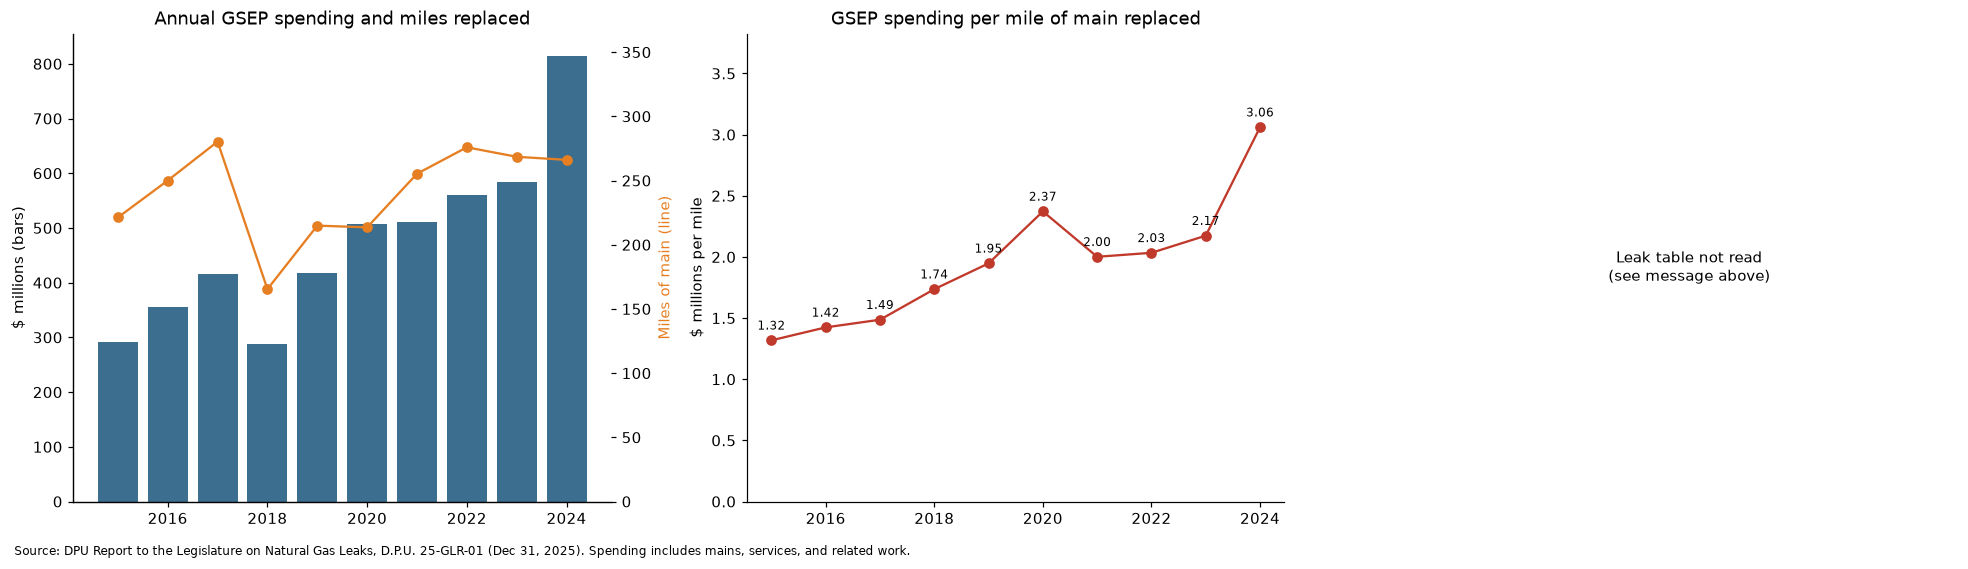

In [48]:
!pip install -q pypdf

import os, re
import requests
import pandas as pd
import matplotlib.pyplot as plt
from pypdf import PdfReader

RAW, PROC, FIG = "data_raw", "data_processed", "figures"
for d in (RAW, PROC, FIG):
    os.makedirs(d, exist_ok=True)

SOURCE_URL = "https://malegislature.gov/Bills/194/SD3561.pdf"
SOURCE_NAME = "DPU Report to the Legislature on Natural Gas Leaks, D.P.U. 25-GLR-01 (Dec 31, 2025)"
PDF_PATH = os.path.join(RAW, "dpu_25_glr_01.pdf")

# 1) Download the official report (once)
if not os.path.exists(PDF_PATH):
    r = requests.get(SOURCE_URL, timeout=120, headers={"User-Agent": "Mozilla/5.0"})
    r.raise_for_status()
    with open(PDF_PATH, "wb") as f:
        f.write(r.content)

text = "\n".join(page.extract_text() or "" for page in PdfReader(PDF_PATH).pages)
flat = re.sub(r"\s+", " ", text)   # one line, for sentences and tables that wrap across lines

# 2) Annual GSEP results (reconciliation filings): spending, miles of main, services
pattern = (r"(20\d\d) GSEPs: \$([\d,.]+) million (?:expended )?to replace ([\d,.]+) miles of "
           r"leak-prone mains and ([\d,]+) leak-prone services")
rows = []
for m in re.finditer(pattern, flat):
    rows.append({"year": int(m.group(1)),
                 "spend_musd": float(m.group(2).replace(",", "")),
                 "main_miles": float(m.group(3).replace(",", "")),
                 "services": int(m.group(4).replace(",", "")),
                 "source_text": m.group(0)})
gsep = pd.DataFrame(rows).drop_duplicates("year").sort_values("year").reset_index(drop=True)
if gsep.empty:
    raise ValueError("No GSEP rows found; the PDF text layout may have changed")

gsep["spend_per_mile_musd"] = gsep["spend_musd"] / gsep["main_miles"]
gsep["cum_spend_busd"] = gsep["spend_musd"].cumsum() / 1000
gsep["cum_miles"] = gsep["main_miles"].cumsum()
gsep["source"] = SOURCE_NAME
gsep.to_csv(os.path.join(PROC, "gsep_annual.csv"), index=False)

# 3) Open leaks at year end, by grade (table "Gas Leaks by Grade 2014-2024")
yr = re.search(r"((?:20\d\d\s+){5,}20\d\d)", flat[flat.find("Gas Leaks by Grade"):])
years = [int(y) for y in yr.group(1).split()] if yr else []
leak_rows = {}
for label in ["Grade 1", "Grade 2", "Grade 3", "Total"]:
    hit = re.search(rf"{label}\s+((?:\d[\d,]*\s+){{{max(len(years) - 1, 1)}}}\d[\d,]*)", flat) if years else None
    if hit:
        leak_rows[label] = [int(n.replace(",", "")) for n in hit.group(1).split()]

if years and len(leak_rows) == 4:
    leaks = pd.DataFrame(leak_rows, index=years).sort_index().rename_axis("year")
    leaks.to_csv(os.path.join(PROC, "gas_leaks_by_grade.csv"))
else:
    print("Could not read the leak table. Here is the text around it:\n")
    i = text.find("Gas Leaks by Grade")
    print(text[i:i + 800])
    leaks = None

# 4) Show the extracted data and where each number came from
print("Source:", SOURCE_NAME, "\n", SOURCE_URL, "\n")
display(gsep[["year", "spend_musd", "main_miles", "services", "spend_per_mile_musd",
              "cum_spend_busd", "cum_miles"]].round(2))
print("\nExact sentences the numbers were extracted from:")
for s in gsep["source_text"]:
    print(" -", s)
if leaks is not None:
    display(leaks)

# 5) Headline numbers
first, last = gsep.iloc[0], gsep.iloc[-1]
print(f"\n{int(first.year)}-{int(last.year)}: ${last.cum_spend_busd:.2f} billion spent, "
      f"{last.cum_miles:,.0f} miles of main replaced")
print(f"Spending per mile: ${first.spend_per_mile_musd:.2f}M ({int(first.year)}) -> "
      f"${last.spend_per_mile_musd:.2f}M ({int(last.year)}), "
      f"{last.spend_per_mile_musd / first.spend_per_mile_musd - 1:+.0%}")
print(f"Miles per year: {first.main_miles:.0f} ({int(first.year)}) -> {last.main_miles:.0f} ({int(last.year)})")
if leaks is not None:
    print(f"Open leaks: {leaks['Total'].iloc[0]:,} ({leaks.index[0]}) -> {leaks['Total'].iloc[-1]:,} "
          f"({leaks.index[-1]}), {leaks['Total'].iloc[-1] / leaks['Total'].iloc[0] - 1:+.0%}")

# 6) Charts
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].bar(gsep["year"], gsep["spend_musd"], color="#3b6e8f")
a0 = ax[0].twinx()
a0.plot(gsep["year"], gsep["main_miles"], marker="o", color="#e67e22")
ax[0].set(title="Annual GSEP spending and miles replaced", ylabel="$ millions (bars)")
a0.set_ylabel("Miles of main (line)", color="#e67e22")
a0.set_ylim(0, gsep["main_miles"].max() * 1.3)

ax[1].plot(gsep["year"], gsep["spend_per_mile_musd"], marker="o", color="#c0392b")
for x, y in zip(gsep["year"], gsep["spend_per_mile_musd"]):
    ax[1].annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)
ax[1].set(title="GSEP spending per mile of main replaced", ylabel="$ millions per mile",
          ylim=(0, gsep["spend_per_mile_musd"].max() * 1.25))

if leaks is not None:
    ax[2].stackplot(leaks.index, leaks["Grade 1"], leaks["Grade 2"], leaks["Grade 3"],
                    labels=["Grade 1 (hazardous)", "Grade 2", "Grade 3"],
                    colors=["#c0392b", "#e67e22", "#9aa5b1"])
    ax[2].set(title="Open gas leaks at year end, statewide", ylabel="Leaks")
    ax[2].legend(loc="upper right")
else:
    ax[2].text(0.5, 0.5, "Leak table not read\n(see message above)", ha="center", va="center")
    ax[2].set_axis_off()

for a in ax:
    a.spines[["top", "right"]].set_visible(False)
fig.text(0.01, -0.02, f"Source: {SOURCE_NAME}. Spending includes mains, services, and related work.", fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(FIG, "10_gsep_spending.png"), bbox_inches="tight")
plt.show()

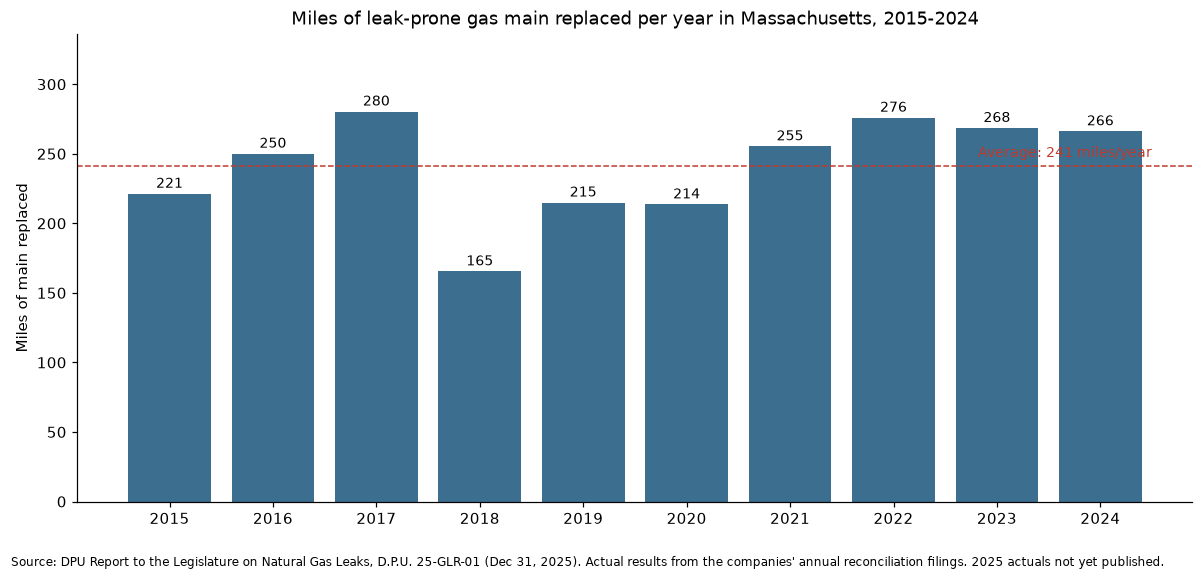

Total 2015-2024: 2,411 miles | average 241/year | lowest 165 (2018) | highest 280 (2017)


In [49]:
# Part 2, Cell 13: miles of leak-prone main replaced per year (from DPU's official report)
import os, re
import requests
import pandas as pd
import matplotlib.pyplot as plt

PROC, RAW, FIG = "data_processed", "data_raw", "figures"
for d in (PROC, RAW, FIG):
    os.makedirs(d, exist_ok=True)
CSV = os.path.join(PROC, "gsep_annual.csv")
SOURCE_URL = "https://malegislature.gov/Bills/194/SD3561.pdf"
SOURCE_NAME = "DPU Report to the Legislature on Natural Gas Leaks, D.P.U. 25-GLR-01 (Dec 31, 2025)"

if os.path.exists(CSV):
    gsep = pd.read_csv(CSV)
else:
    from pypdf import PdfReader
    pdf = os.path.join(RAW, "dpu_25_glr_01.pdf")
    if not os.path.exists(pdf):
        r = requests.get(SOURCE_URL, timeout=120, headers={"User-Agent": "Mozilla/5.0"})
        r.raise_for_status()
        open(pdf, "wb").write(r.content)
    flat = re.sub(r"\s+", " ", " ".join(p.extract_text() or "" for p in PdfReader(pdf).pages))
    rows = re.findall(r"(20\d\d) GSEPs: \$([\d,.]+) million (?:expended )?to replace ([\d,.]+) miles", flat)
    gsep = pd.DataFrame(rows, columns=["year", "spend_musd", "main_miles"]).astype(float).drop_duplicates("year")

gsep = gsep.sort_values("year")
years, miles = gsep["year"].astype(int), gsep["main_miles"]
avg = miles.mean()

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(years.astype(str), miles, color="#3b6e8f")
for b, m in zip(bars, miles):
    ax.annotate(f"{m:.0f}", (b.get_x() + b.get_width() / 2, m), textcoords="offset points",
                xytext=(0, 4), ha="center", fontsize=9)
ax.axhline(avg, color="#c0392b", linestyle="--", linewidth=1)
ax.annotate(f"Average: {avg:.0f} miles/year", (len(years) - 0.5, avg), textcoords="offset points",
            xytext=(0, 6), ha="right", color="#c0392b", fontsize=9)

ax.set(title=f"Miles of leak-prone gas main replaced per year in Massachusetts, {years.min()}-{years.max()}",
       ylabel="Miles of main replaced", ylim=(0, miles.max() * 1.2))
ax.spines[["top", "right"]].set_visible(False)
fig.text(0.01, -0.04, f"Source: {SOURCE_NAME}. Actual results from the companies' annual reconciliation filings. "
         f"{years.max() + 1} actuals not yet published.", fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(FIG, "11_miles_replaced_per_year.png"), bbox_inches="tight")
plt.show()

print(f"Total {years.min()}-{years.max()}: {miles.sum():,.0f} miles | average {avg:.0f}/year | "
      f"lowest {miles.min():.0f} ({years[miles.idxmin()]}) | highest {miles.max():.0f} ({years[miles.idxmax()]})")

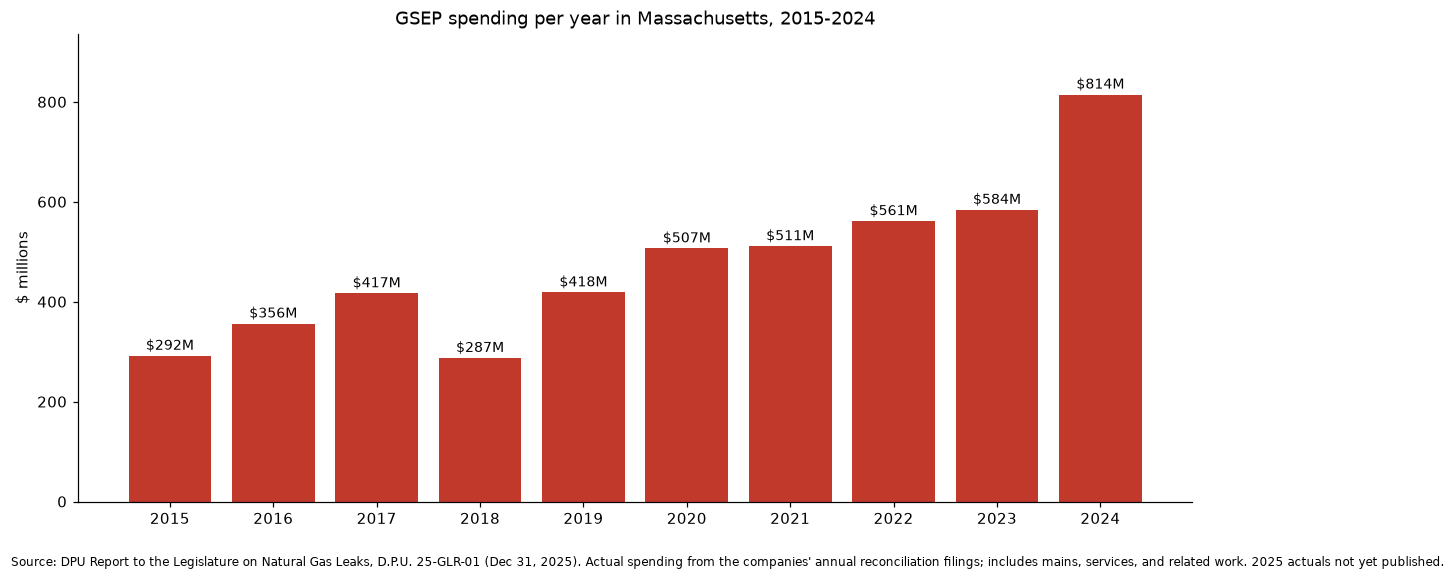

Total 2015-2024: $4.75 billion
2015: $291.6M -> 2024: $814.4M (2.8x, about 12% per year)


In [50]:
# Part 2, Cell 14: GSEP money spent per year (from DPU's official report)
import os, re
import requests
import pandas as pd
import matplotlib.pyplot as plt

PROC, RAW, FIG = "data_processed", "data_raw", "figures"
for d in (PROC, RAW, FIG):
    os.makedirs(d, exist_ok=True)
CSV = os.path.join(PROC, "gsep_annual.csv")
SOURCE_URL = "https://malegislature.gov/Bills/194/SD3561.pdf"
SOURCE_NAME = "DPU Report to the Legislature on Natural Gas Leaks, D.P.U. 25-GLR-01 (Dec 31, 2025)"

if os.path.exists(CSV):
    gsep = pd.read_csv(CSV)
else:
    from pypdf import PdfReader
    pdf = os.path.join(RAW, "dpu_25_glr_01.pdf")
    if not os.path.exists(pdf):
        r = requests.get(SOURCE_URL, timeout=120, headers={"User-Agent": "Mozilla/5.0"})
        r.raise_for_status()
        open(pdf, "wb").write(r.content)
    flat = re.sub(r"\s+", " ", " ".join(p.extract_text() or "" for p in PdfReader(pdf).pages))
    rows = re.findall(r"(20\d\d) GSEPs: \$([\d,.]+) million (?:expended )?to replace ([\d,.]+) miles", flat)
    gsep = pd.DataFrame(rows, columns=["year", "spend_musd", "main_miles"])
    gsep = gsep.apply(lambda c: c.str.replace(",", "")).astype(float).drop_duplicates("year")

gsep = gsep.sort_values("year")
years, spend = gsep["year"].astype(int), gsep["spend_musd"]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(years.astype(str), spend, color="#c0392b")
for b, s in zip(bars, spend):
    ax.annotate(f"${s:,.0f}M", (b.get_x() + b.get_width() / 2, s), textcoords="offset points",
                xytext=(0, 4), ha="center", fontsize=9)

ax.set(title=f"GSEP spending per year in Massachusetts, {years.min()}-{years.max()}",
       ylabel="$ millions", ylim=(0, spend.max() * 1.15))
ax.spines[["top", "right"]].set_visible(False)
fig.text(0.01, -0.04, f"Source: {SOURCE_NAME}. Actual spending from the companies' annual reconciliation filings; "
         f"includes mains, services, and related work. {years.max() + 1} actuals not yet published.", fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(FIG, "12_gsep_spending_per_year.png"), bbox_inches="tight")
plt.show()

growth = (spend.iloc[-1] / spend.iloc[0]) ** (1 / (len(spend) - 1)) - 1
print(f"Total {years.min()}-{years.max()}: ${spend.sum() / 1000:,.2f} billion")
print(f"{years.min()}: ${spend.iloc[0]:,.1f}M -> {years.max()}: ${spend.iloc[-1]:,.1f}M "
      f"({spend.iloc[-1] / spend.iloc[0]:.1f}x, about {growth:.0%} per year)")

Cell 1: setup and load

In [31]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

PROC_DIR, RAW_DIR, FIG_DIR = "data_processed", "data_raw", "figures"
os.makedirs(FIG_DIR, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

seg = gpd.read_file(f"{PROC_DIR}/segments_clean.geojson")
wx = pd.read_csv(f"{PROC_DIR}/annual_weather.csv")

seg["GEOID"] = seg["GEOID"].astype(str)
seg["is_ej"] = seg["is_ej"].astype(bool)
seg["miles"] = seg["length_m"] / 1609.34
seg["units_per_100m"] = seg["res_units"] / (seg["length_m"] / 100)
seg["income_plot"] = seg["median_hh_income"].clip(upper=250000)   # 250,001 is the Census "over $250k" cap

def wmean(x, w):
    x, w = np.asarray(x, float), np.asarray(w, float)
    ok = ~np.isnan(x)
    return (x[ok] * w[ok]).sum() / w[ok].sum()

def save(fig, name):
    fig.savefig(f"{FIG_DIR}/{name}.png", bbox_inches="tight")

print(f"{len(seg):,} street segments, {seg['miles'].sum():,.0f} miles, {seg['GEOID'].nunique()} block groups")

17,820 street segments, 1,032 miles, 581 block groups


Cell 2: overview of the street network

,count,mean,std,min,25%,50%,75%,max
seg_id,17820.0,11635.96,8121.04,1.00,4680.75,9729.00,18189.25,2.767300e+04
addr_min,16077.0,228.13,517.00,1.00,1.00,51.00,202.00,5.319000e+03
addr_max,16077.0,258.85,518.23,1.00,34.00,98.00,241.00,5.398000e+03
length_m,17820.0,93.18,81.99,1.92,44.02,72.57,116.18,1.637810e+03
n_addresses,17820.0,4.89,7.07,0.00,0.00,2.00,7.00,6.800000e+01
n_parcels,17820.0,8.67,22.17,0.00,0.00,3.00,9.00,9.540000e+02
res_units,17820.0,11.73,23.75,0.00,0.00,3.00,14.00,5.250000e+02
med_yr_built,17820.0,1923.94,30.43,1752.00,1903.00,1915.00,1935.00,2.025000e+03
pct_heat_pump,17820.0,0.00,0.05,0.00,0.00,0.00,0.00,1.000000e+00
total_value,17820.0,14098841.30,58793684.00,0.00,0.00,2967100.00,9818800.00,2.664063e+09


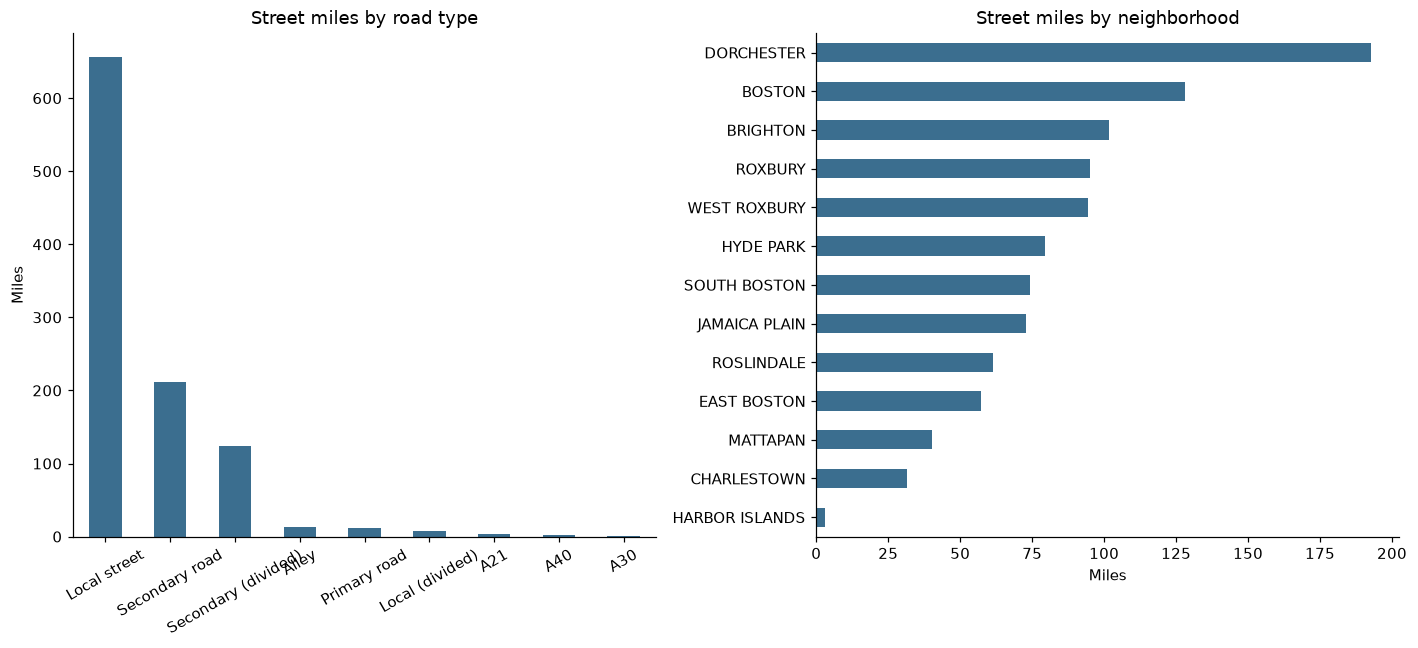

In [32]:
display(seg.drop(columns="geometry").describe().T.round(2))

CFCC_NAMES = {"A31": "Secondary road", "A35": "Secondary (divided)", "A41": "Local street",
              "A45": "Local (divided)", "A25": "Primary road", "A73": "Alley"}
by_class = seg.groupby(seg["CFCC"].map(CFCC_NAMES).fillna(seg["CFCC"]))["miles"].sum().sort_values(ascending=False)
by_nbhd = seg.groupby("NBHD_L")["miles"].sum().sort_values()

fig, ax = plt.subplots(1, 2, figsize=(13, 6))
by_class.plot.bar(ax=ax[0], color="#3b6e8f")
ax[0].set(title="Street miles by road type", ylabel="Miles", xlabel="")
ax[0].tick_params(axis="x", rotation=30)
by_nbhd.plot.barh(ax=ax[1], color="#3b6e8f")
ax[1].set(title="Street miles by neighborhood", xlabel="Miles", ylabel="")
plt.tight_layout(); save(fig, "01_network_overview"); plt.show()

Cell 3: how old are the streets? (building age as a stand-in for pipe age)

age_band
Before 1900      10.7
1900-1919        40.2
1920-1939        24.9
1940-1969        15.5
1970 or later     8.7

Street miles with buildings older than 1940: 76%
Segments with building age borrowed from street/neighborhood: 34.3%


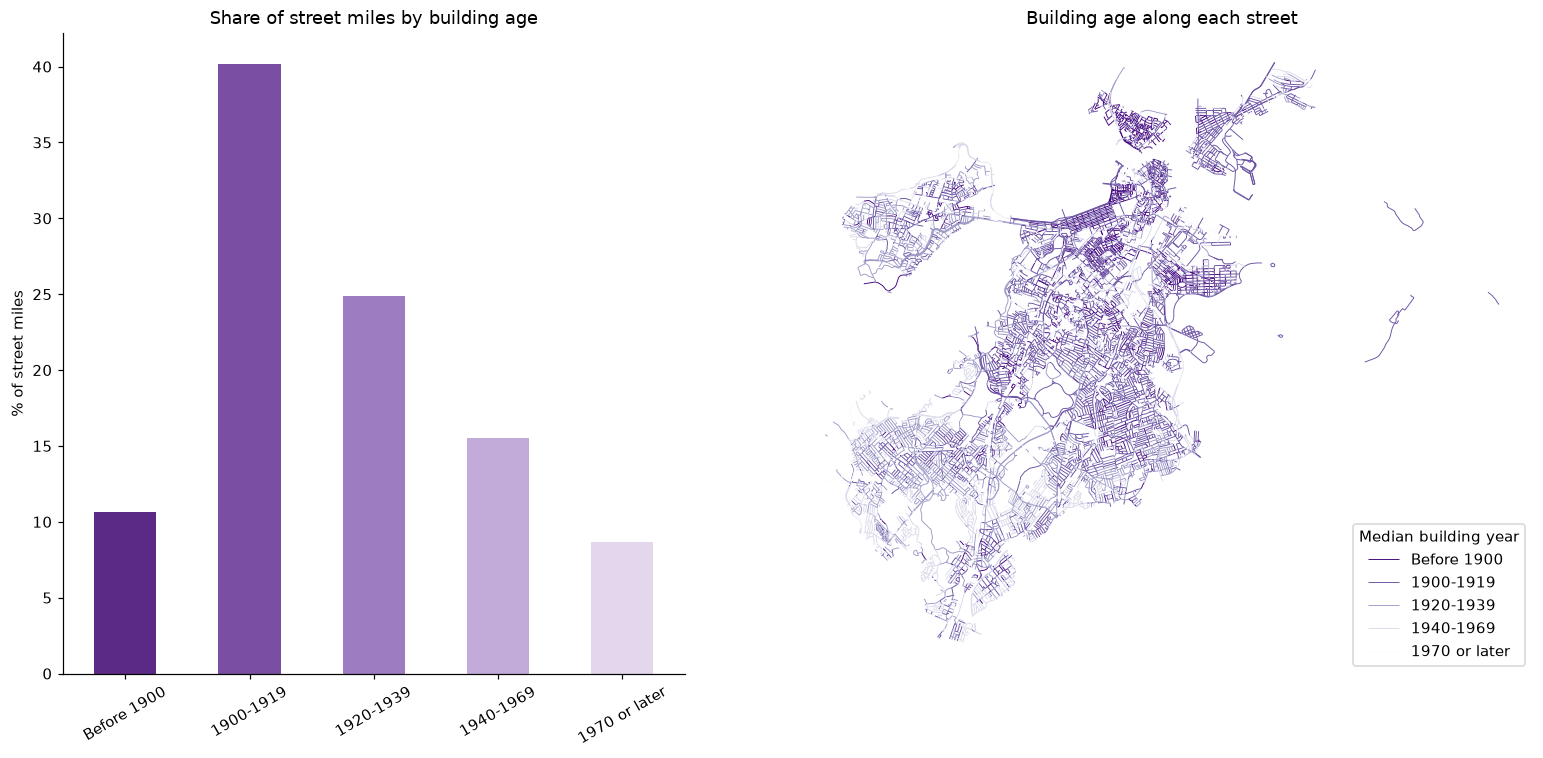

In [33]:
# Gas mains were usually laid when a street was first built up, so the age of the buildings
# along a street is a reasonable proxy for the vintage (and likely material) of the main under it.
bins = [1700, 1900, 1920, 1940, 1970, 2030]
labels = ["Before 1900", "1900-1919", "1920-1939", "1940-1969", "1970 or later"]
seg["age_band"] = pd.cut(seg["med_yr_built"], bins=bins, labels=labels, right=False)

share = seg.groupby("age_band", observed=False)["miles"].sum() / seg["miles"].sum() * 100
print(share.round(1).to_string())
print(f"\nStreet miles with buildings older than 1940: {share.iloc[:3].sum():.0f}%")
print(f"Segments with building age borrowed from street/neighborhood: {seg['yr_built_imputed'].mean():.1%}")

fig, ax = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={"width_ratios": [1, 1.5]})
share.plot.bar(ax=ax[0], color=["#5b2a86", "#7a4fa3", "#9e7cc1", "#c3abd9", "#e3d7ee"])
ax[0].set(title="Share of street miles by building age", ylabel="% of street miles", xlabel="")
ax[0].tick_params(axis="x", rotation=30)
seg.plot(column="age_band", categorical=True, cmap="Purples_r", linewidth=0.6, legend=True, ax=ax[1],
         legend_kwds={"title": "Median building year", "loc": "lower right"})
ax[1].set_title("Building age along each street"); ax[1].set_axis_off()
plt.tight_layout(); save(fig, "02_building_age"); plt.show()

Cell 4: where is gas heat most common? (block group level)

Boston block groups: 581  |  EJ: 79%


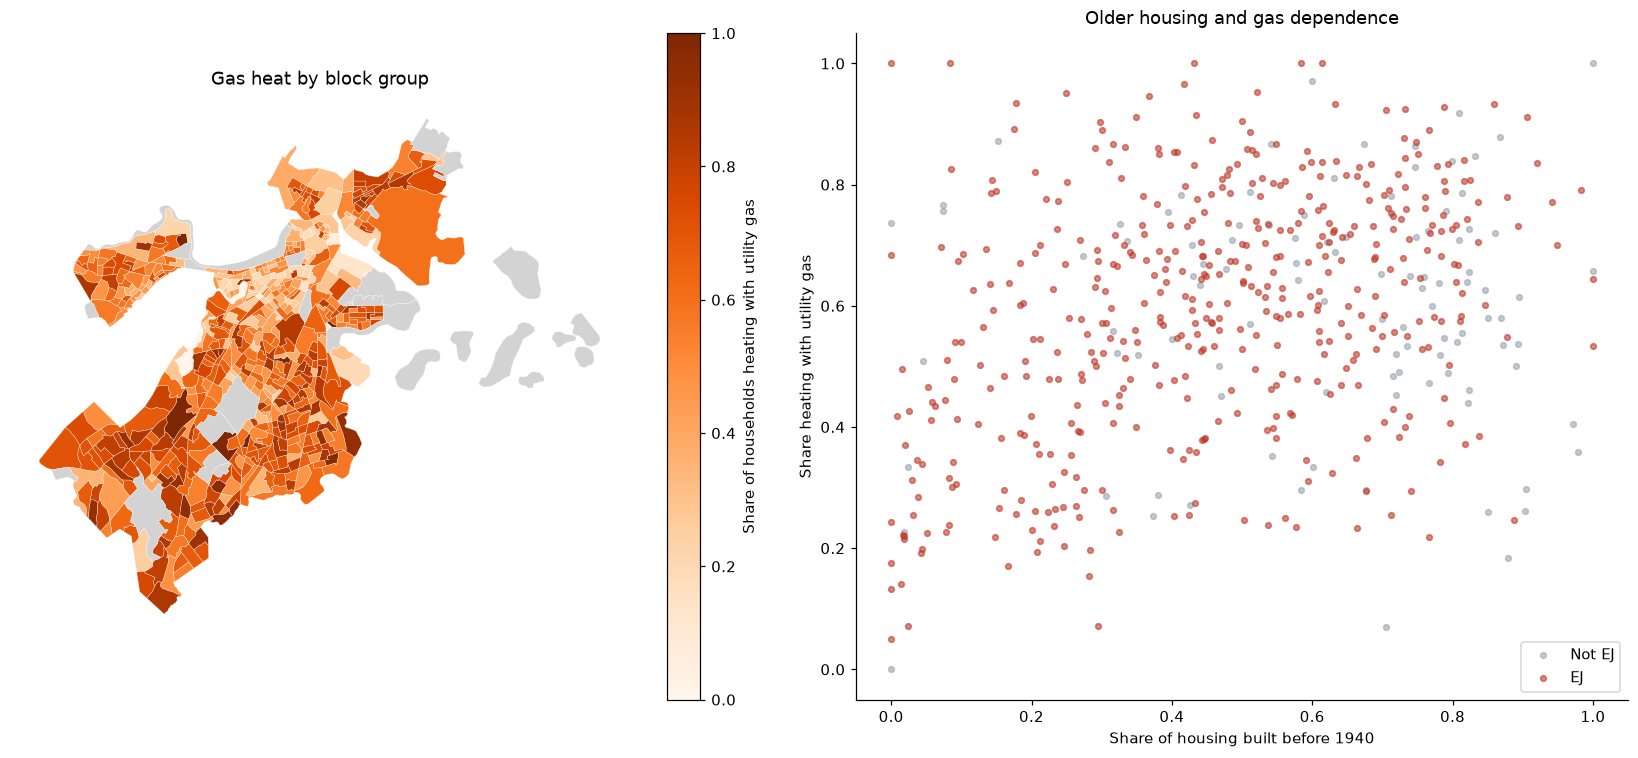

Spearman correlation, pre-1940 housing vs gas heat: 0.29


In [34]:
bg = gpd.read_file(f"{RAW_DIR}/suffolk_blockgroups.geojson")
acs = pd.read_csv(f"{RAW_DIR}/acs_suffolk_blockgroups.csv", dtype={"GEOID": str})
ej_by_bg = seg.groupby("GEOID")["is_ej"].first()

bgb = bg[bg["GEOID"].isin(seg["GEOID"].unique())].merge(acs, on="GEOID")
bgb["is_ej"] = bgb["GEOID"].map(ej_by_bg).fillna(False).astype(bool)
bgb["income_plot"] = bgb["median_hh_income"].clip(upper=250000)
print(f"Boston block groups: {len(bgb)}  |  EJ: {bgb['is_ej'].mean():.0%}")

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
bgb.plot(column="pct_gas_heat", cmap="Oranges", legend=True, ax=ax[0], edgecolor="white", linewidth=0.2,
         missing_kwds={"color": "lightgrey"}, legend_kwds={"label": "Share of households heating with utility gas"})
ax[0].set_title("Gas heat by block group"); ax[0].set_axis_off()

for flag, color, name in [(False, "#9aa5b1", "Not EJ"), (True, "#c0392b", "EJ")]:
    d = bgb[bgb["is_ej"] == flag]
    ax[1].scatter(d["pct_pre1940"], d["pct_gas_heat"], s=14, alpha=0.6, color=color, label=name)
ax[1].set(xlabel="Share of housing built before 1940", ylabel="Share heating with utility gas",
          title="Older housing and gas dependence")
ax[1].legend()
plt.tight_layout(); save(fig, "03_gas_heat"); plt.show()

print("Spearman correlation, pre-1940 housing vs gas heat:",
      bgb[["pct_pre1940", "pct_gas_heat"]].corr(method="spearman").iloc[0, 1].round(2))

Cell 5: does the burden fall more on EJ communities?

,EJ mean,non-EJ mean,difference,95% CI low,95% CI high
measure,,,,,
Gas heat share,0.588,0.592,-0.004,-0.045,0.040
Pre-1940 housing share,0.455,0.616,-0.160,-0.213,-0.108
Renter share,0.669,0.439,0.229,0.177,0.283
Median household income,99442.674,174326.081,-74883.407,-85050.732,-64632.770


Median-building-year, length-weighted: EJ 1926  vs  non-EJ 1922
EJ block groups whose current income is top-coded ($250k+): 8


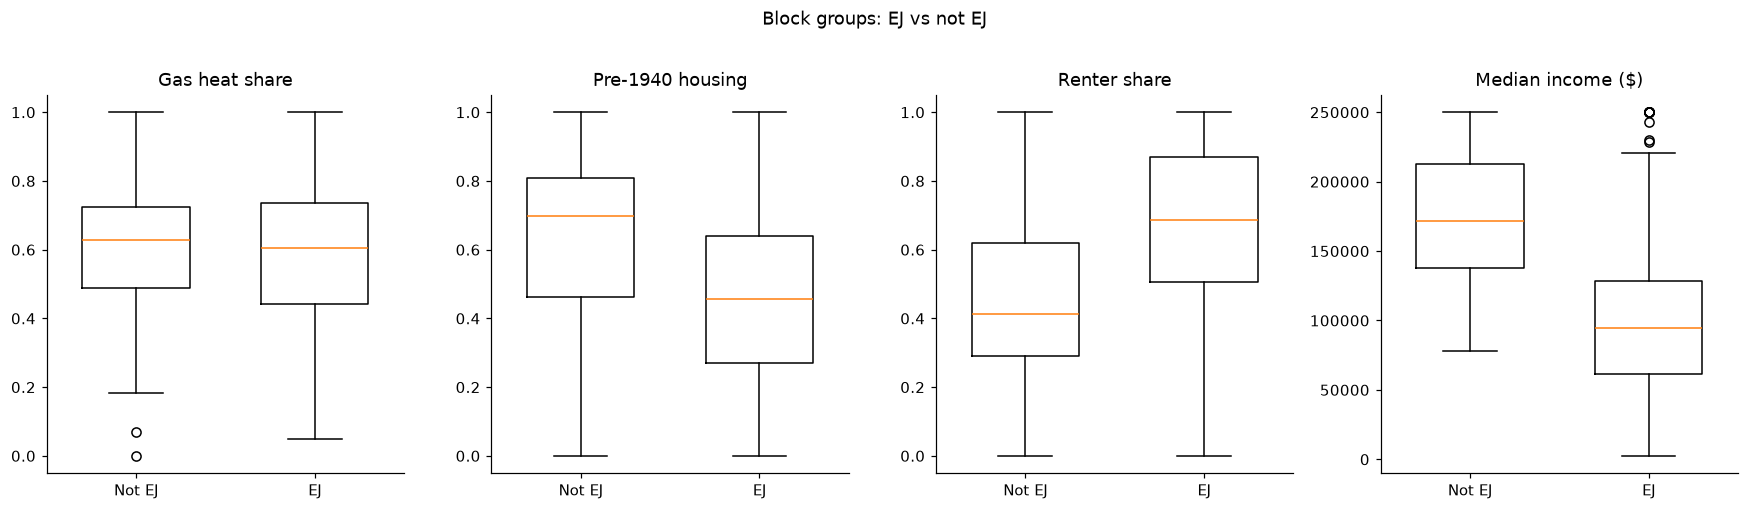

In [35]:
# Census variables are block-group level, so compare block groups (not segments) to avoid counting
# the same block group many times. Bootstrap gives a 95% interval for each difference.
rng = np.random.default_rng(42)

def boot_diff(a, b, n=2000):
    a, b = a.dropna().to_numpy(), b.dropna().to_numpy()
    sims = [rng.choice(a, len(a)).mean() - rng.choice(b, len(b)).mean() for _ in range(n)]
    return a.mean() - b.mean(), *np.percentile(sims, [2.5, 97.5])

rows = []
for col, name in [("pct_gas_heat", "Gas heat share"), ("pct_pre1940", "Pre-1940 housing share"),
                  ("pct_renter", "Renter share"), ("income_plot", "Median household income")]:
    diff, lo, hi = boot_diff(bgb.loc[bgb["is_ej"], col], bgb.loc[~bgb["is_ej"], col])
    rows.append({"measure": name, "EJ mean": bgb.loc[bgb["is_ej"], col].mean(),
                 "non-EJ mean": bgb.loc[~bgb["is_ej"], col].mean(),
                 "difference": diff, "95% CI low": lo, "95% CI high": hi})
equity = pd.DataFrame(rows).set_index("measure")
display(equity.round(3))

# Street-level: building age, weighted by street length
print(f"Median-building-year, length-weighted: EJ {wmean(seg.loc[seg.is_ej, 'med_yr_built'], seg.loc[seg.is_ej, 'miles']):.0f}"
      f"  vs  non-EJ {wmean(seg.loc[~seg.is_ej, 'med_yr_built'], seg.loc[~seg.is_ej, 'miles']):.0f}")

mismatch = bgb[bgb["is_ej"] & (bgb["median_hh_income"] >= 250000)]
print(f"EJ block groups whose current income is top-coded ($250k+): {len(mismatch)}")

fig, ax = plt.subplots(1, 4, figsize=(16, 4.5))
for a_, (col, name) in zip(ax, [("pct_gas_heat", "Gas heat share"), ("pct_pre1940", "Pre-1940 housing"),
                                ("pct_renter", "Renter share"), ("income_plot", "Median income ($)")]):
    a_.boxplot([bgb.loc[~bgb["is_ej"], col].dropna(), bgb.loc[bgb["is_ej"], col].dropna()],
               tick_labels=["Not EJ", "EJ"], widths=0.6)
    a_.set_title(name)
plt.suptitle("Block groups: EJ vs not EJ", y=1.02)
plt.tight_layout(); save(fig, "04_equity"); plt.show()

Cell 6: how do the features relate to each other?

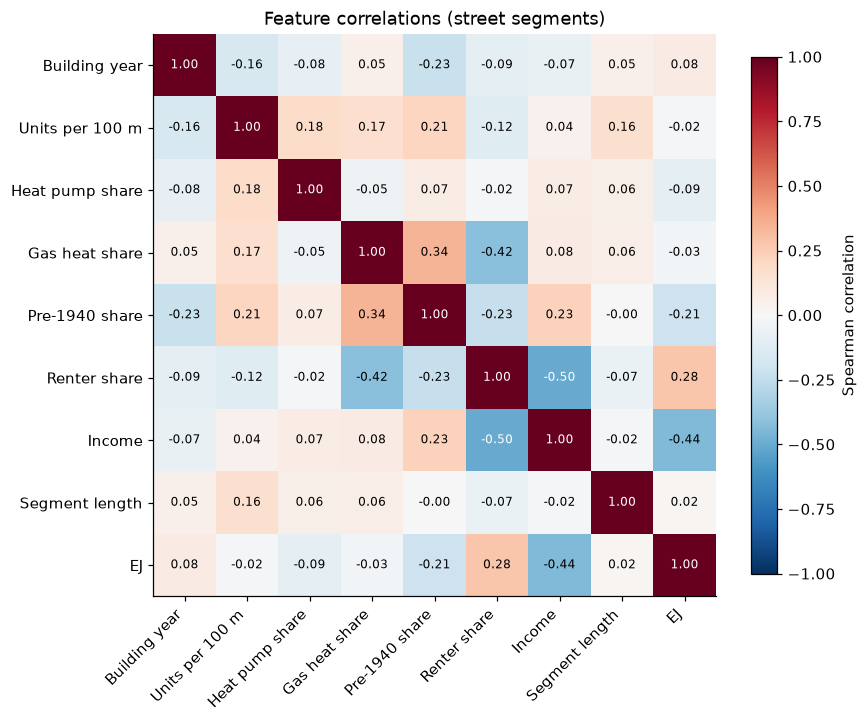

In [36]:
cols = {"med_yr_built": "Building year", "units_per_100m": "Units per 100 m", "pct_heat_pump": "Heat pump share",
        "pct_gas_heat": "Gas heat share", "pct_pre1940": "Pre-1940 share", "pct_renter": "Renter share",
        "income_plot": "Income", "length_m": "Segment length", "is_ej": "EJ"}
corr = seg[list(cols)].astype(float).corr(method="spearman").rename(index=cols, columns=cols)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(corr.iloc[i, j]) > 0.5 else "black")
fig.colorbar(im, shrink=0.8, label="Spearman correlation")
ax.set_title("Feature correlations (street segments)")
plt.tight_layout(); save(fig, "05_correlations"); plt.show()

Cell 7: which streets look like candidates for electrification instead of new pipe?

Low-density cutoff: 7.4 housing units per 100 m of street
Streets passing the screen: 1,654 segments, 97 miles
  of which in EJ block groups: 77%


NBHD_L
WEST ROXBURY     18.7
DORCHESTER       18.3
JAMAICA PLAIN    10.9
BRIGHTON          8.8
HYDE PARK         8.5
BOSTON            8.1
ROXBURY           6.4
ROSLINDALE        6.3
EAST BOSTON       3.3
MATTAPAN          3.1
Name: miles, dtype: float64

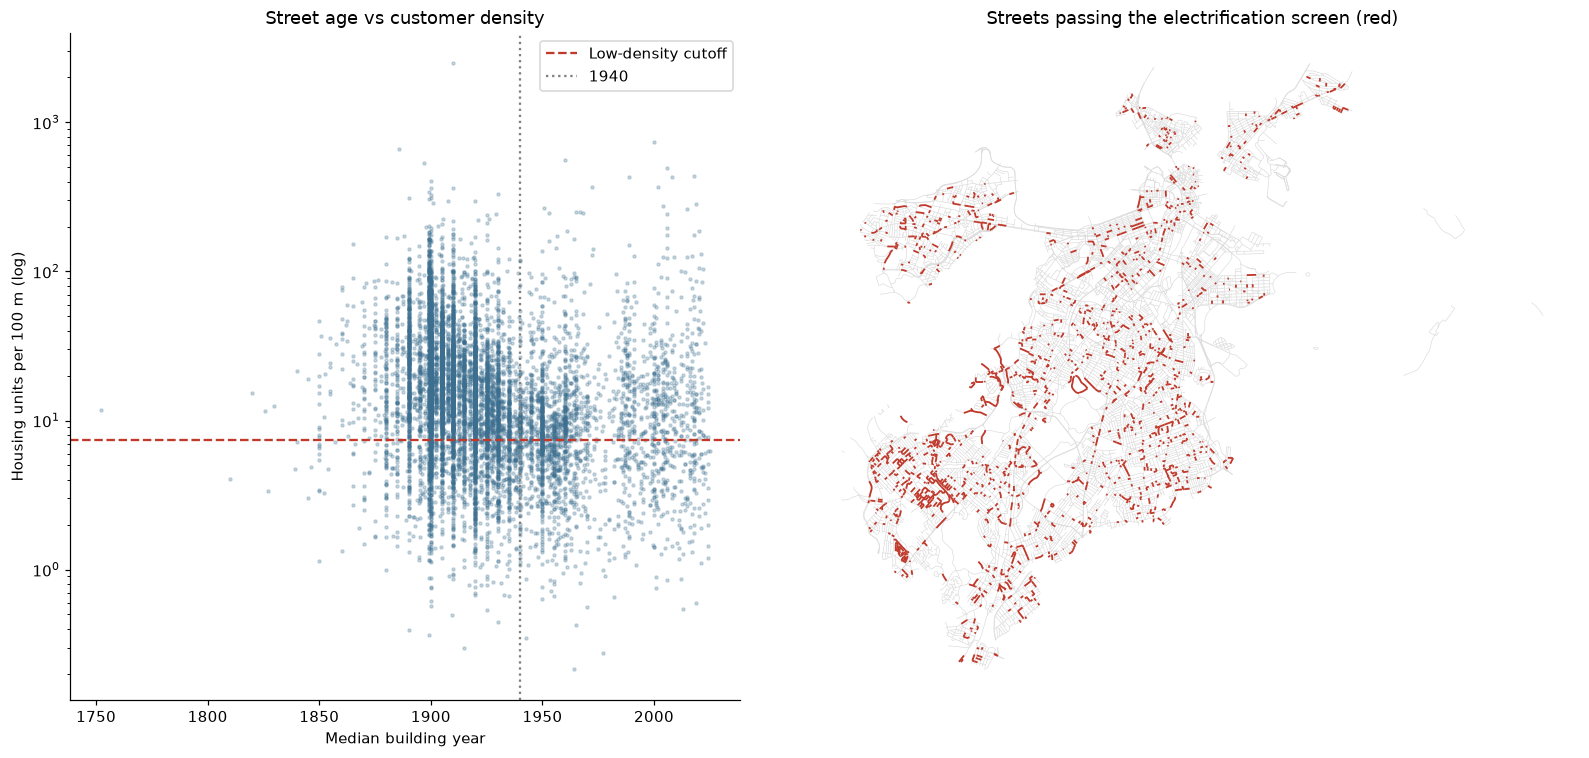

In [37]:
# A first screen only: old streets with few households are where replacing pipe is most expensive per
# customer, so heat pumps or networked geothermal may cost less. Part 3 replaces this with real cost math.
res = seg[seg["res_units"] > 0]
low_density = res["units_per_100m"].quantile(0.25)
seg["npa_screen"] = (seg["med_yr_built"] < 1940) & (seg["res_units"] > 0) & (seg["units_per_100m"] <= low_density)

print(f"Low-density cutoff: {low_density:.1f} housing units per 100 m of street")
print(f"Streets passing the screen: {seg['npa_screen'].sum():,} segments, {seg.loc[seg.npa_screen, 'miles'].sum():.0f} miles")
print(f"  of which in EJ block groups: {seg.loc[seg.npa_screen, 'is_ej'].mean():.0%}")
display(seg[seg["npa_screen"]].groupby("NBHD_L")["miles"].sum().sort_values(ascending=False).head(10).round(1))

fig, ax = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={"width_ratios": [1, 1.3]})
ax[0].scatter(res["med_yr_built"], res["units_per_100m"] + 0.1, s=4, alpha=0.25, color="#3b6e8f")
ax[0].set_yscale("log")
ax[0].axhline(low_density, color="#c0392b", linestyle="--", label="Low-density cutoff")
ax[0].axvline(1940, color="grey", linestyle=":", label="1940")
ax[0].set(xlabel="Median building year", ylabel="Housing units per 100 m (log)",
          title="Street age vs customer density"); ax[0].legend()
seg.plot(ax=ax[1], color="#d9d9d9", linewidth=0.4)
seg[seg["npa_screen"]].plot(ax=ax[1], color="#c0392b", linewidth=1.2)
ax[1].set_title("Streets passing the electrification screen (red)"); ax[1].set_axis_off()
plt.tight_layout(); save(fig, "06_npa_screen"); plt.show()

Cell 8: weather trends (freeze-thaw cycles stress old cast-iron mains)

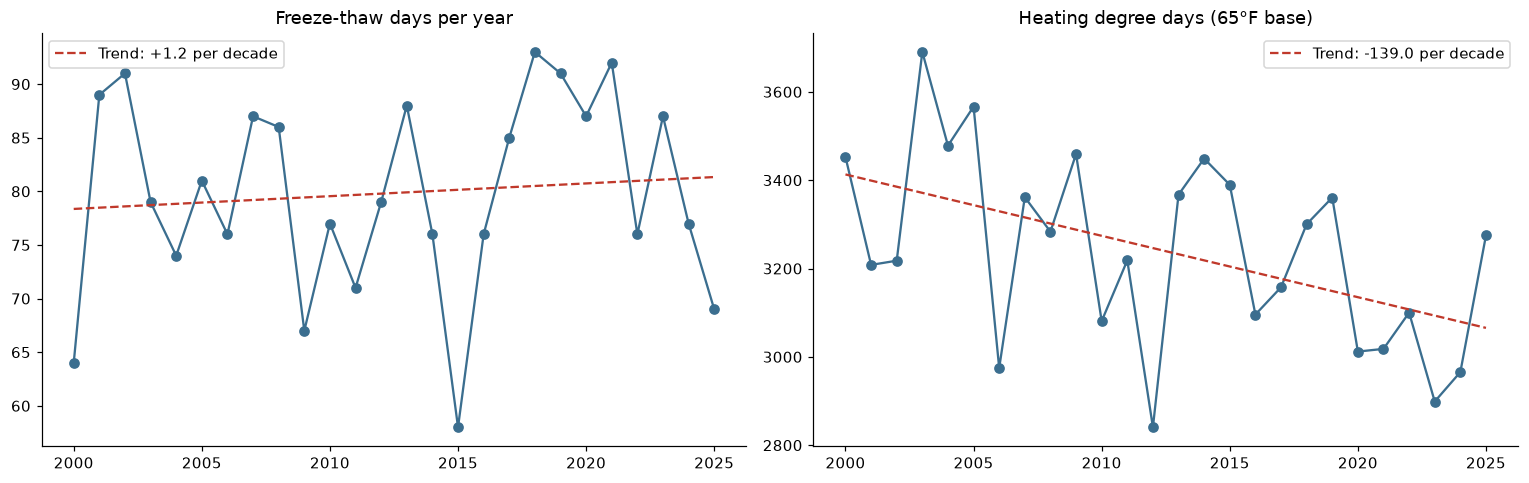

In [38]:
full = wx[wx["year"] < pd.Timestamp.today().year]   # drop the partial current year

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for a_, col, name in [(ax[0], "freeze_thaw_days", "Freeze-thaw days per year"), (ax[1], "hdd", "Heating degree days (65°F base)")]:
    a_.plot(full["year"], full[col], marker="o", color="#3b6e8f")
    slope, intercept = np.polyfit(full["year"], full[col], 1)
    a_.plot(full["year"], slope * full["year"] + intercept, linestyle="--", color="#c0392b",
            label=f"Trend: {slope * 10:+.1f} per decade")
    a_.set(title=name, xlabel=""); a_.legend()
plt.tight_layout(); save(fig, "07_weather"); plt.show()

Cell 9: neighborhood summary table

In [39]:
t = seg.assign(w_gas=seg["pct_gas_heat"] * seg["miles"], w_ej=seg["is_ej"] * seg["miles"],
               w_old=(seg["med_yr_built"] < 1940) * seg["miles"], w_npa=seg["npa_screen"] * seg["miles"])
nb = t.groupby("NBHD_L").agg(miles=("miles", "sum"), units=("res_units", "sum"), w_gas=("w_gas", "sum"),
                             w_ej=("w_ej", "sum"), w_old=("w_old", "sum"), w_npa=("w_npa", "sum"))
summary = pd.DataFrame({
    "Street miles": nb["miles"],
    "Pre-1940 streets %": nb["w_old"] / nb["miles"] * 100,
    "Gas heat share %": nb["w_gas"] / nb["miles"] * 100,
    "EJ streets %": nb["w_ej"] / nb["miles"] * 100,
    "Housing units per mile": nb["units"] / nb["miles"],
    "Electrification-screen miles": nb["w_npa"],
}).sort_values("Pre-1940 streets %", ascending=False).round(1)

summary.to_csv(f"{FIG_DIR}/neighborhood_summary.csv")
display(summary)

,Street miles,Pre-1940 streets %,Gas heat share %,EJ streets %,Housing units per mile,Electrification-screen miles
NBHD_L,,,,,,
HARBOR ISLANDS,2.9,100.0,61.3,0.0,0.0,0.0
EAST BOSTON,57.4,87.1,66.5,95.3,255.1,3.3
BOSTON,127.9,84.2,40.0,71.0,311.1,8.1
JAMAICA PLAIN,72.9,83.9,61.3,76.0,189.7,10.9
DORCHESTER,192.8,83.0,65.9,93.9,219.4,18.3
CHARLESTOWN,31.6,79.1,53.4,50.5,194.4,1.9
ROSLINDALE,61.3,78.9,72.4,91.2,171.3,6.3
SOUTH BOSTON,74.3,76.4,57.0,17.8,225.7,2.4
ROXBURY,95.0,74.0,59.1,98.7,151.5,6.4


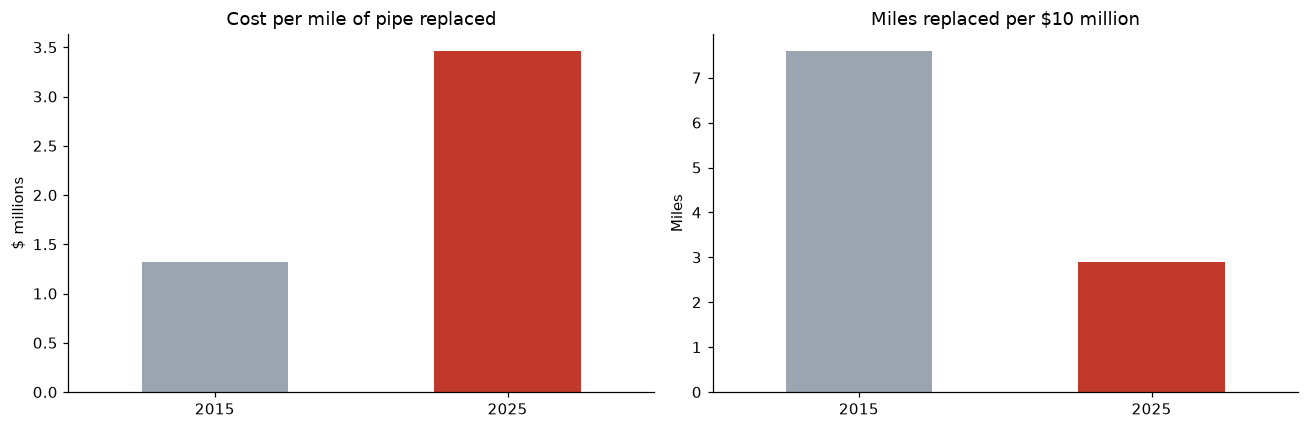

Remaining leak-prone pipe statewide: 4,049 miles
At 2025 cost per mile, replacing all of it: $14.0 billion
Boston street network in this project: 1,032 miles


In [40]:
# GSEP context from public sources (DPU April 2025 order; DPU 2024 annual report)
cost_per_mile = pd.Series({2015: 1.32, 2025: 3.46})        # $ millions per mile replaced
miles_per_10m = pd.Series({2015: 7.59, 2025: 2.89})
remaining_miles_ma = 4049

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
cost_per_mile.plot.bar(ax=ax[0], color=["#9aa5b1", "#c0392b"])
ax[0].set(title="Cost per mile of pipe replaced", ylabel="$ millions", xlabel="")
miles_per_10m.plot.bar(ax=ax[1], color=["#9aa5b1", "#c0392b"])
ax[1].set(title="Miles replaced per $10 million", ylabel="Miles", xlabel="")
for a_ in ax:
    a_.tick_params(axis="x", rotation=0)
plt.tight_layout(); save(fig, "08_gsep_cost_trend"); plt.show()

print(f"Remaining leak-prone pipe statewide: {remaining_miles_ma:,} miles")
print(f"At 2025 cost per mile, replacing all of it: ${remaining_miles_ma * cost_per_mile[2025] / 1000:,.1f} billion")
print(f"Boston street network in this project: {seg['miles'].sum():,.0f} miles")

In [41]:
# BERDO: reported energy use (including natural gas) for large Boston buildings
import os, re
import requests
import pandas as pd

REFRESH = True   # True = re-download and re-check; set to False after it works once

DATA_DIR = "data_raw"
os.makedirs(DATA_DIR, exist_ok=True)
CKAN = "https://data.boston.gov/api/3/action"
SESSION = requests.Session()
SESSION.headers.update({"User-Agent": "boston-gas-pipe-triage (portfolio project)"})

def path(name):
    return os.path.join(DATA_DIR, name)

def download(url, filename):
    r = SESSION.get(url, timeout=300, allow_redirects=True)
    r.raise_for_status()
    with open(path(filename), "wb") as f:
        f.write(r.content)

def ckan_search(query, rows=10):
    r = SESSION.get(f"{CKAN}/package_search", params={"q": query, "rows": rows}, timeout=90)
    r.raise_for_status()
    out = []
    for pkg in r.json()["result"]["results"]:
        for rsc in pkg.get("resources", []):
            out.append({"dataset": pkg["title"], "resource": rsc.get("name"),
                        "format": (rsc.get("format") or "").upper(), "url": rsc.get("url"),
                        "datastore": rsc.get("datastore_active", False), "modified": rsc.get("last_modified")})
    return pd.DataFrame(out, columns=["dataset", "resource", "format", "url", "datastore", "modified"])

def best_table(xlsx_path):
    """Check every sheet with header on row 0 and row 1; return the biggest table that has a gas column."""
    best = None
    for header_row in (0, 1):
        for name, df in pd.read_excel(xlsx_path, sheet_name=None, header=header_row).items():
            gas_cols = [c for c in df.columns if re.search(r"gas", str(c), re.I)]
            if gas_cols and len(df) > 500 and (best is None or len(df) > len(best[2])):
                best = (name, header_row, df)
    return best

berdo = ckan_search("Building Emissions Reduction and Disclosure BERDO", rows=5)
berdo = berdo[berdo["dataset"].str.contains("BERDO|Building Emissions", case=False, na=False)]

if REFRESH and os.path.exists(path("berdo_latest.csv")):
    os.remove(path("berdo_latest.csv"))
    print("Removed the old BERDO file to re-check the newest one")

cands = (berdo[berdo["format"].eq("XLSX")]
         .dropna(subset=["modified"])
         .sort_values("modified", ascending=False)
         .head(6))

if os.path.exists(path("berdo_latest.csv")):
    print("Using cached berdo_latest.csv")
else:
    for _, row in cands.iterrows():
        fname = row["url"].split("/")[-1]
        print("Checking:", row["modified"], fname)
        download(row["url"], "berdo_try.xlsx")
        found = best_table(path("berdo_try.xlsx"))
        if found:
            name, header_row, df = found
            df = df.dropna(axis=1, how="all")
            df.columns = [str(c).strip() for c in df.columns]
            df.to_csv(path("berdo_latest.csv"), index=False)
            with open(path("berdo_source.txt"), "w") as f:
                f.write(f"{fname} | sheet: {name} | header row: {header_row} | modified: {row['modified']}\n")
            print(f"  -> using sheet '{name}' (header row {header_row}): {len(df):,} buildings")
            break
        print("  -> skipped (no sheet with a gas column)")
    for f in ["berdo_try.xlsx", "berdo_2025_check.xlsx"]:
        if os.path.exists(path(f)):
            os.remove(path(f))

if os.path.exists(path("berdo_latest.csv")):
    berdo_df = pd.read_csv(path("berdo_latest.csv"), low_memory=False)
    if os.path.exists(path("berdo_source.txt")):
        print("\nSource:", open(path("berdo_source.txt")).read().strip())
    print("BERDO buildings:", berdo_df.shape)
    print([c for c in berdo_df.columns if re.search(r"gas|address|parcel|street|sq|year|use|zip", str(c), re.I)])
else:
    print("No BERDO file with gas data found in the newest 6 XLSX files")

Removed the old BERDO file to re-check the newest one
Checking: 2026-03-03T16:59:12.629324 2025-reported-energy-and-water-metrics.xlsx
  -> using sheet 'Data Disclosure' (header row 1): 5,580 buildings

Source: 2025-reported-energy-and-water-metrics.xlsx | sheet: Data Disclosure | header row: 1 | modified: 2026-03-03T16:59:12.629324
BERDO buildings: (5580, 52)
['Tax Parcel ID', 'Building Address', 'Building Address City', 'Building Address Zip Code', 'Parcel Address', 'Parcel Address City', 'Parcel Address Zip Code', 'Reported Gross Floor Area (Sq Ft)', 'Reported Enclosed Parking Area (Sq Ft)', 'BERDO Emissions Gross Floor Area (Sq Ft)', 'Site EUI (Energy Use Intensity kBtu/ft²)', 'Natural Gas Usage (kBtu)', 'Natural Gas Emissions (kgCO2e)', 'First Emissions Compliance Year (Projected)']


In [42]:
download(cands.iloc[0]["url"], "berdo_2025_check.xlsx")
peek = pd.read_excel(path("berdo_2025_check.xlsx"), sheet_name="Data Disclosure", header=None, nrows=6)
display(peek)
print(pd.read_excel(path("berdo_2025_check.xlsx"), sheet_name="Data Disclosure").columns.tolist())

,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
0,Building Details,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Compliance,NaN,NaN,Energy Use Details,NaN,NaN,NaN,NaN,Notes,NaN
1,BERDO ID,Tax Parcel ID,Property Owner Name,Building Address,Building Address City,Building Address Zip Code,Parcel Address,Parcel Address City,Parcel Address Zip Code,Reported Gross Floor Area (Sq Ft),...,Reporting Compliance Status,First Emissions Compliance Year (Projected),Community Choice Electricity Participation,Renewable Energy Purchased through a Power Pur...,Renewable Energy Certificate (REC) Purchase,Backup Generator,Battery Storage,Electric Vehicle (EV) Charging,Corresponding Campus ID,Notes
2,100001,303060001,1 LOVEJOY WHARF BOSTON REALTY LLC,NaN,Boston,2114,160 170 N Washington St,Boston,2114,251688,...,in compliance,2025,No,No,No,Yes,No,No,NaN,NaN
3,100002,304794000,10 TEMPLE PLACE LP,2-24 Temple Pl,Boston,2111,24 2 Temple Pl,Boston,2111,135344,...,in compliance,2025,Unsure,No,No,Yes,No,No,NaN,NaN
4,100003,602757045,10-20 CHANNEL CENTER,20 Channel Center St,Boston,2127,20 30 Channel Center St,Boston,2127,255383,...,in compliance,2025,No,No,No,Yes,No,No,NaN,NaN
5,100005,304718000,10-24 SCHOOL STREET,24 School St,Boston,2108,12 Province St,Boston,2108,134789,...,in compliance,2025,No,No,No,Yes,No,No,NaN,NaN


['Building Details', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Energy Usage', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Compliance ', 'Unnamed: 45', 'Unnamed: 46', 'Energy Use Details ', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Notes ', 'Unnamed: 53']


Downloading: 2025-reported-energy-and-water-metrics.xlsx
Sheet 'Data Disclosure': 5,578 buildings, 52 columns
Using columns: {'gas': 'Natural Gas Usage (kBtu)', 'electricity': 'Electricity Usage (kWh)', 'floor area': 'Reported Gross Floor Area (Sq Ft)', 'property type': 'Largest Property Type'}

Buildings using gas: 57%
Total reported gas use: 119.4 million therms/year
Share used by the top 10% of buildings: 73%
Median gas share of building energy (gas users): 87%


,buildings,million_therms,pct_using_gas
Largest Property Type,,,
Multifamily Housing,2104,38.94,0.89
College/University,310,18.72,0.55
Office,455,10.36,0.69
Manufacturing/Industrial Plant,32,10.27,0.78
Laboratory,50,7.75,0.86
K-12 School,167,6.51,0.97
Hotel,66,5.33,0.98
Hospital (General Medical & Surgical),24,4.87,0.71
Museum,12,1.33,0.75


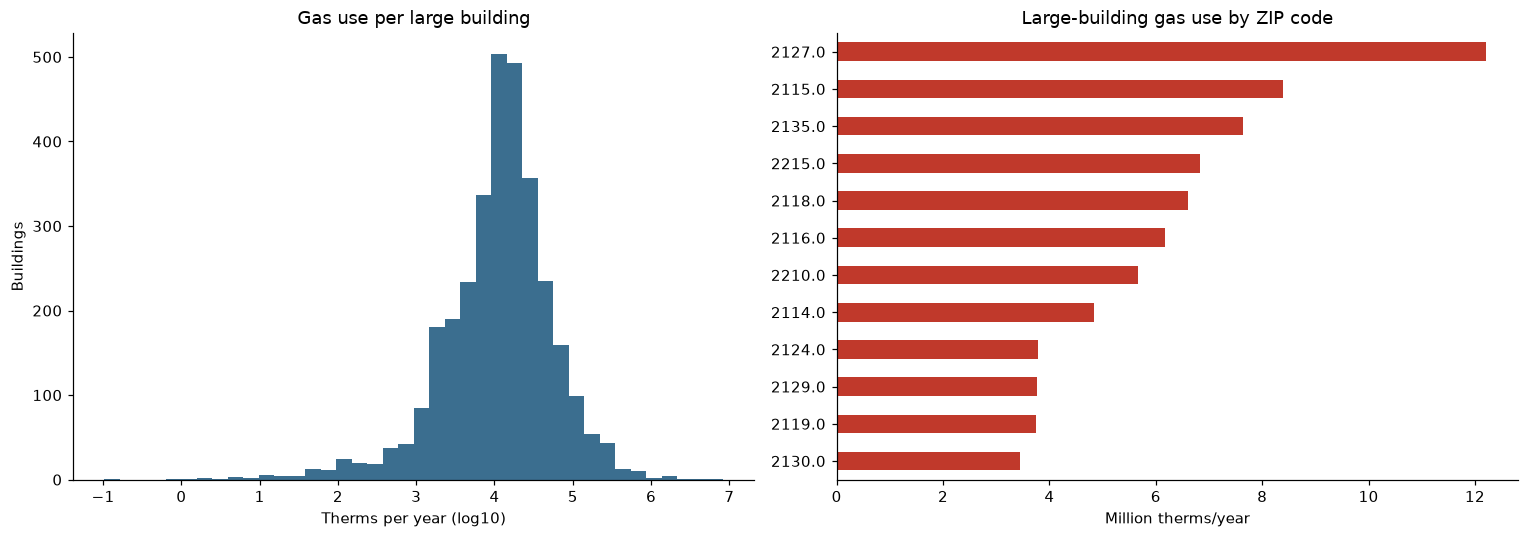

In [45]:
# Part 2, Cell 11: BERDO large-building gas use (self-contained)
import os, re
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

RAW, PROC, FIG = "data_raw", "data_processed", "figures"
for d in (RAW, PROC, FIG):
    os.makedirs(d, exist_ok=True)
XLSX = os.path.join(RAW, "berdo_2025_reported.xlsx")

# 1) Download the newest BERDO file (only if not already saved)
if not os.path.exists(XLSX):
    r = requests.get("https://data.boston.gov/api/3/action/package_search",
                     params={"q": "Building Emissions Reduction and Disclosure BERDO", "rows": 5}, timeout=90)
    res = [rs for pkg in r.json()["result"]["results"] if "BERDO" in pkg["title"].upper()
           for rs in pkg["resources"] if (rs.get("format") or "").upper() == "XLSX" and rs.get("last_modified")]
    newest = max(res, key=lambda rs: rs["last_modified"])
    print("Downloading:", newest["url"].split("/")[-1])
    with open(XLSX, "wb") as f:
        f.write(requests.get(newest["url"], timeout=300, headers={"User-Agent": "Mozilla/5.0"}).content)

# 2) Read the data sheet with the real headers on row 1
sheets = pd.read_excel(XLSX, sheet_name=None, header=1)
sheet_name, berdo = max(sheets.items(), key=lambda kv: len(kv[1]))
berdo.columns = [str(c).strip() for c in berdo.columns]
berdo = berdo.dropna(axis=1, how="all").dropna(subset=["Tax Parcel ID"])
print(f"Sheet '{sheet_name}': {len(berdo):,} buildings, {berdo.shape[1]} columns")

def col(pattern):
    hits = [c for c in berdo.columns if re.search(pattern, c, re.I)]
    return hits[0] if hits else None

GAS, ELEC = col(r"natural gas usage"), col(r"electricity usage")
AREA, PTYPE = col(r"reported gross floor area"), col(r"largest property type|property type")
ZIP, STATUS = col(r"building address zip"), col(r"reporting compliance status")
print("Using columns:", {"gas": GAS, "electricity": ELEC, "floor area": AREA, "property type": PTYPE})

# 3) Clean numbers
for c in [GAS, ELEC, AREA]:
    if c:
        berdo[c] = pd.to_numeric(berdo[c], errors="coerce")
berdo["gas_therms"] = berdo[GAS].fillna(0) / 100                     # 1 therm = 100 kBtu
berdo["uses_gas"] = berdo["gas_therms"] > 0
berdo["gas_therms_per_sqft"] = berdo["gas_therms"] / berdo[AREA].where(berdo[AREA] > 0)
if ELEC:
    total_e = berdo[GAS].fillna(0) + berdo[ELEC].fillna(0)
    berdo["gas_share_of_energy"] = berdo[GAS].fillna(0) / total_e.where(total_e > 0)
berdo["Tax Parcel ID"] = (berdo["Tax Parcel ID"].astype(str).str.replace(r"\.0$", "", regex=True)
                          .str.replace(r"\D", "", regex=True).str.zfill(10))

berdo.to_csv(os.path.join(PROC, "berdo_clean.csv"), index=False)

# 4) Headline numbers
g = berdo["gas_therms"]
top10 = g.nlargest(max(1, int(len(g) * 0.10))).sum() / g.sum()
print(f"\nBuildings using gas: {berdo['uses_gas'].mean():.0%}")
print(f"Total reported gas use: {g.sum() / 1e6:,.1f} million therms/year")
print(f"Share used by the top 10% of buildings: {top10:.0%}")
if ELEC:
    print(f"Median gas share of building energy (gas users): {berdo.loc[berdo.uses_gas, 'gas_share_of_energy'].median():.0%}")

if PTYPE:
    by_type = (berdo.groupby(PTYPE)
                    .agg(buildings=("gas_therms", "size"), million_therms=("gas_therms", lambda s: s.sum() / 1e6),
                         pct_using_gas=("uses_gas", "mean"))
                    .sort_values("million_therms", ascending=False).head(10).round(2))
    display(by_type)

# 5) Charts
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(np.log10(g[g > 0]), bins=40, color="#3b6e8f")
ax[0].set(title="Gas use per large building", xlabel="Therms per year (log10)", ylabel="Buildings")
if ZIP:
    by_zip = berdo.groupby(berdo[ZIP].astype(str).str.zfill(5))["gas_therms"].sum().div(1e6).nlargest(12)
    by_zip.sort_values().plot.barh(ax=ax[1], color="#c0392b")
    ax[1].set(title="Large-building gas use by ZIP code", xlabel="Million therms/year", ylabel="")
for a in ax:
    a.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(os.path.join(FIG, "09_berdo_gas.png"), bbox_inches="tight")
plt.show()